In [1]:
# !pip install pennylane
# !pip install pennylane pennylane-lightning[gpu]

In [2]:
import pennylane as qml
from pennylane import numpy as np
from pennylane.templates import StronglyEntanglingLayers
import torch
import matplotlib.pyplot as plt
from torch.nn.functional import relu
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from skimage.transform import resize

/Users/aleksandrak/Desktop/thesis_experiments/.venv/lib/python3.12/site-packages/pennylane/__init__.py:212: PennyLaneDeprecationWarning: PennyLane v0.44 has dropped maintainence support for NumPy < 2.0.0. You have version 1.26.4 installed. Future versions of PennyLane will not work with NumPy<2.0. Please consider upgrading NumPy using `python -m pip install numpy --upgrade`. 
  warnings.warn(


### Dataset Preparation


First, we load the MNIST dataset from openML.
- X is the pixel data
- y is the labels
- converting everything to `uint8` here to ensure all values are integers in [0, 255]

In [3]:
# loading mnist from keras.datasets
from keras.datasets import mnist
(X_train_full, y_train_full), (X_test_full, y_test_full) = mnist.load_data()
X = np.concatenate((X_train_full, X_test_full), axis=0)
y = np.concatenate((y_train_full, y_test_full), axis=0)

X = X.astype(np.uint8) # better to convert for binerization
y = y.astype(np.uint8)
# digits = load_digits()

# X = digits.data        # shape (1797, 64)
# y = digits.target      # labels 0–9


2026-03-05 15:36:40.228163: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [4]:
X.shape

(70000, 28, 28)

Next, we focus on 2 classes, i.e. binary classification.
Here, I've been experimenting with different classes, and I stopped on 4 vs 9, cause they have more subtle difference in pixels, they are similar looking.

In [5]:
# focus on binary classification
mask = (y == 0) | (y == 1)

X, y = X[mask], y[mask]
X.shape

(14780, 28, 28)

In [6]:
print("Unique labels:", np.unique(y))

Unique labels: [0 1]


In [7]:
y = np.where(y == 0, -1, 1)
print("Unique labels:", np.unique(y))

Unique labels: [-1  1]


- I take only the first `n_samples`.
- I convert X to a NumPy array, and shuffling the data randomly

In [8]:
n_samples = 360 # restricting to 6000 samples for now

X = X.values if hasattr(X, "values") else X # safer conversion

X = X[:n_samples]
y = y[:n_samples]

Now, I normalise pixel intensities.
- [0, 255] -> [0, 1]
- reshaping images back to 2D for resizing, i.e to 28x28 array with float values between 0 and 1.

In [9]:
X = X / 255.0
X = X.reshape(-1, 28, 28)

print(X.shape)
print("Pixel range:", X.min(), X.max())

(360, 28, 28)
Pixel range: 0.0 1.0


And now I reduce images to 8x8 + flattening to (, 64)
- resize -> flatten -> normalize

In [10]:
# convert each 28x28 binarised image to 8x8, then flatten to length 64
def to_8x8_vector(img_row):
    img_8x8 = resize(
        img_row,
        (8, 8),
        anti_aliasing=False,
        preserve_range=True,
        order=1 # controlling interpolation
    )
    img_8x8 = img_8x8.flatten().astype(float)
    # img_8x8 -= img_8x8.mean()
    norm = np.linalg.norm(img_8x8)
    if norm > 0:
        img_8x8 /= norm
    else:
        img_8x8[0] = 1.0
      # should be shape (64,)
    return img_8x8

# apply transformation to all images
X_8x8 = np.array([to_8x8_vector(x) for x in X], dtype=float)
X_8x8.shape

(360, 64)

In [11]:
# sanity check, make sure no NaNs exist and all vectors are normalised, i.e. norm is around 1
print("Any NaNs?", np.isnan(X_8x8).any())
print("Norm check:", np.min(np.linalg.norm(X_8x8, axis=1)), np.max(np.linalg.norm(X_8x8, axis=1)))

Any NaNs? False
Norm check: 0.9999999999999998 1.0000000000000002


I'm gonna do the splitting here, and carry both representations consistently.
- qek inputs: (64,) flattened and normalized vectors, for quantum kernel embedding
- qjpeg: 28x28 images

In [12]:
idx = np.arange(n_samples)

idx_train, idx_test, y_train, y_test = train_test_split(
    idx, y, test_size=0.2, random_state=42, stratify=y, shuffle=True
)

# QEK inputs (8x8 -> 64 -> normed)
X_train_qek = X_8x8[idx_train]
X_test_qek  = X_8x8[idx_test]

print("QEK train/test:", X_train_qek.shape, X_test_qek.shape)
print("Labels train/test:", y_train.shape, y_test.shape)

QEK train/test: (288, 64) (72, 64)
Labels train/test: (288,) (72,)


Data preparation is done.

### Device

In [13]:
n_qubits = 6
dev_var = qml.device("default.qubit", wires=n_qubits)

### Quantum Model

In [14]:
@qml.qnode(dev_var, diff_method="parameter-shift")
def quantum_model(x, params):
    """A variational quantum model."""

    # embedding
    qml.AmplitudeEmbedding(
        x,
        wires=range(n_qubits),
        normalize=False  # already normalized
    )


    # trainable measurement
    StronglyEntanglingLayers(params, wires=range(n_qubits))
    return qml.expval(qml.PauliZ(0))

def quantum_model_plus_bias(x, params, bias):
    """Adding a bias."""
    return quantum_model(x, params) + bias

def hinge_loss(predictions, targets):
    """Implements the hinge loss."""
    all_ones = torch.ones_like(targets)
    hinge_loss = all_ones - predictions * targets
    # trick: since the max(0,x) function is not differentiable,
    # use the mathematically equivalent relu instead
    hinge_loss = relu(hinge_loss)
    return hinge_loss

def quantum_model_train(n_layers, steps, batch_size):
    """Train the quantum model defined above."""

    params = np.random.random((n_layers, n_qubits, 3))
    params_torch = torch.tensor(params, requires_grad=True)
    bias_torch = torch.tensor(0.0, requires_grad=True)

    opt = torch.optim.Adam([params_torch, bias_torch], lr=0.1)

    loss_history = []
    for i in range(steps):

        batch_ids = np.random.choice(len(X_train_qek), batch_size)

        X_batch = X_train_qek[batch_ids]
        y_batch = y_train[batch_ids]

        X_batch_torch = torch.tensor(X_batch, requires_grad=False)
        y_batch_torch = torch.tensor(y_batch, requires_grad=False)

        def closure():
            opt.zero_grad()
            preds = torch.stack(
                [quantum_model_plus_bias(x, params_torch, bias_torch) for x in X_batch_torch]
            )
            loss = torch.mean(hinge_loss(preds, y_batch_torch))

            # bookkeeping
            current_loss = loss.detach().numpy().item()
            loss_history.append(current_loss)
            if i % 10 == 0:
                print("step", i, ", loss", current_loss)

            loss.backward()
            return loss

        opt.step(closure)

    return params_torch, bias_torch, loss_history


def quantum_model_predict(X_pred, trained_params, trained_bias):
    """Predict using the quantum model defined above."""

    p = []
    for x in X_pred:

        x_torch = torch.tensor(x)
        pred_torch = quantum_model_plus_bias(x_torch, trained_params, trained_bias)
        pred = pred_torch.detach().numpy().item()
        if pred > 0:
            pred = 1
        else:
            pred = -1

        p.append(pred)
    return p


In [15]:
params_1, bias_1, history_1 = quantum_model_train(
    n_layers=1,
    steps=200,
    batch_size=16
)

preds_1 = quantum_model_predict(X_test_qek, params_1, bias_1)
acc_1 = np.mean(preds_1 == y_test)

print("Validation accuracy (1 layer):", acc_1)

step 0 , loss 1.1063354117561934
step 10 , loss 1.1005581138655622
step 20 , loss 0.9775027307474087
step 30 , loss 0.415899203385913
step 40 , loss 0.740835880024692
step 50 , loss 0.6675001341890991
step 60 , loss 0.670144837076468
step 70 , loss 0.90707015771504
step 80 , loss 0.4438283316250395
step 90 , loss 0.8601641828903532
step 100 , loss 0.37666215906197903
step 110 , loss 0.7421024480668769
step 120 , loss 0.6619060896852271
step 130 , loss 0.8080813361230645
step 140 , loss 0.7459633679286076
step 150 , loss 0.8780362383909153
step 160 , loss 0.7185294241694129
step 170 , loss 0.7089339137506698
step 180 , loss 0.6593645583849728
step 190 , loss 0.6227342781187277
Validation accuracy (1 layer): 0.5555555555555556


In [16]:
params_2, bias_2, history_2 = quantum_model_train(
    n_layers=2,
    steps=200,
    batch_size=16
)

preds_2 = quantum_model_predict(X_test_qek, params_2, bias_2)
acc_2 = np.mean(preds_2 == y_test)

print("Validation accuracy (2 layers):", acc_2)


step 0 , loss 1.209562365273277
step 10 , loss 0.6605612135396729
step 20 , loss 0.6560933104044264
step 30 , loss 0.742195356079104
step 40 , loss 0.48917552077361737
step 50 , loss 0.8152731726756371
step 60 , loss 0.6365335295322239
step 70 , loss 0.6280445938053603
step 80 , loss 0.5240515221706913
step 90 , loss 0.5989748701589951
step 100 , loss 0.6675200969948877
step 110 , loss 0.7662039388079258
step 120 , loss 0.8745897630387746
step 130 , loss 0.7286696106792401
step 140 , loss 0.8478193534661662
step 150 , loss 0.9574305923102635
step 160 , loss 1.054765056889382
step 170 , loss 0.7124194091435794
step 180 , loss 0.5482776801648126
step 190 , loss 0.7521011436798625
Validation accuracy (2 layers): 0.6388888888888888


In [17]:
params_4, bias_4, history_4 = quantum_model_train(
    n_layers=4,
    steps=200,
    batch_size=16
)

preds_4 = quantum_model_predict(X_test_qek, params_4, bias_4)
acc_4 = np.mean(preds_4 == y_test)

print("Validation accuracy (4 layers):", acc_4)

step 0 , loss 0.8959899724413435
step 10 , loss 0.6221980041014786
step 20 , loss 0.4230198764941453
step 30 , loss 0.5298720186463451
step 40 , loss 0.5322686388526603
step 50 , loss 0.6471143427308231
step 60 , loss 0.6665418761946265
step 70 , loss 0.3994669941784815
step 80 , loss 0.5367294172746266
step 90 , loss 0.48927464374518237
step 100 , loss 0.41355141287993624
step 110 , loss 0.37646956415075955
step 120 , loss 0.48426713522801546
step 130 , loss 0.38008568535879594
step 140 , loss 0.4295232597654244
step 150 , loss 0.38330566314654885
step 160 , loss 0.3333137559799331
step 170 , loss 0.39955031692939463
step 180 , loss 0.31450323287122833
step 190 , loss 0.3824940232720729
Validation accuracy (4 layers): 0.9305555555555556


In [18]:
params_5, bias_5, history_5 = quantum_model_train(
    n_layers=5,
    steps=200,
    batch_size=16
)

preds_5 = quantum_model_predict(X_test_qek, params_5, bias_5)
acc_5 = np.mean(preds_5 == y_test)

print("Validation accuracy (5 layers):", acc_5)

step 0 , loss 0.9202390223705634
step 10 , loss 0.5149644416838217
step 20 , loss 0.5208617853594055
step 30 , loss 0.5189039986922919
step 40 , loss 0.6054089460885728
step 50 , loss 0.7230435068378073
step 60 , loss 0.506188319423341
step 70 , loss 0.5669024292941008
step 80 , loss 0.587544740335353
step 90 , loss 0.48667109416465176
step 100 , loss 0.5320952712484446
step 110 , loss 0.5162872733559445
step 120 , loss 0.3145128889959481
step 130 , loss 0.5115127742346308
step 140 , loss 0.4330255842297749
step 150 , loss 0.4501109148842942
step 160 , loss 0.5803560579605908
step 170 , loss 0.43320268297724035
step 180 , loss 0.3984585528782413
step 190 , loss 0.5895375735001793
Validation accuracy (5 layers): 1.0


In [29]:
params_6, bias_6, history_6 = quantum_model_train(
    n_layers=6,
    steps=200,
    batch_size=16
)

preds_6 = quantum_model_predict(X_test_qek, params_6, bias_6)
acc_6 = np.mean(preds_6 == y_test)

print("Validation accuracy (6 layers):", acc_6)

step 0 , loss 0.9202068215413086
step 10 , loss 0.5750380100861021
step 20 , loss 0.44640956710727664
step 30 , loss 0.5653439891900913
step 40 , loss 0.4925278883834875
step 50 , loss 0.4718564322770371
step 60 , loss 0.5224981265444
step 70 , loss 0.7967998452961759
step 80 , loss 0.48898900650300137
step 90 , loss 0.5171749376617129
step 100 , loss 0.4170365547052054
step 110 , loss 0.48511475229883905
step 120 , loss 0.43650338856020743
step 130 , loss 0.42511407550588975
step 140 , loss 0.3769718972139907
step 150 , loss 0.42202978730708846
step 160 , loss 0.4620459067259143
step 170 , loss 0.44378215036240093
step 180 , loss 0.3599677988106301
step 190 , loss 0.34238118393806677
Validation accuracy (6 layers): 0.8611111111111112


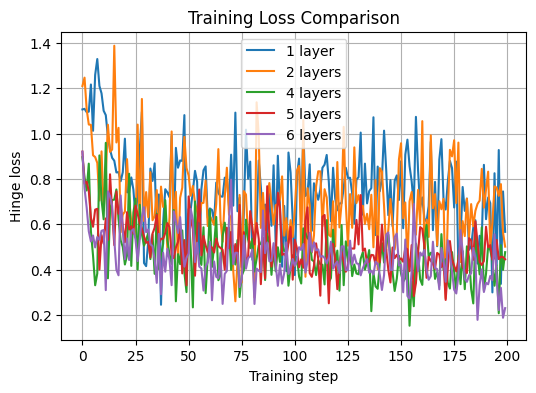

In [30]:
plt.figure(figsize=(6,4))

plt.plot(history_1, label="1 layer")
plt.plot(history_2, label="2 layers")
plt.plot(history_4, label="4 layers")
plt.plot(history_5, label="5 layers")
plt.plot(history_6, label="6 layers")

plt.xlabel("Training step")
plt.ylabel("Hinge loss")
plt.title("Training Loss Comparison")
plt.legend()
plt.grid(True)

plt.show()

Minibatching makes everything noisy, so I'm gonna use smoothing to reveal the actual trend.

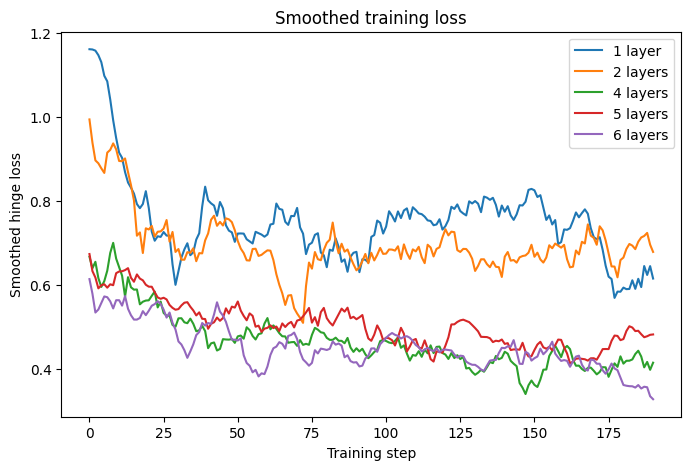

In [31]:
def smooth(x, w=10):
    return np.convolve(x, np.ones(w) / w, mode="valid")

plt.figure(figsize=(8,5))
plt.plot(smooth(history_1), label="1 layer")
plt.plot(smooth(history_2), label="2 layers")
plt.plot(smooth(history_4), label="4 layers")
plt.plot(smooth(history_5), label="5 layers")
plt.plot(smooth(history_6), label="6 layers")

plt.xlabel("Training step")
plt.ylabel("Smoothed hinge loss")
plt.title("Smoothed training loss")
plt.legend()
plt.grif=True

plt.show()

There's also Mean Loss per Model I can compare...

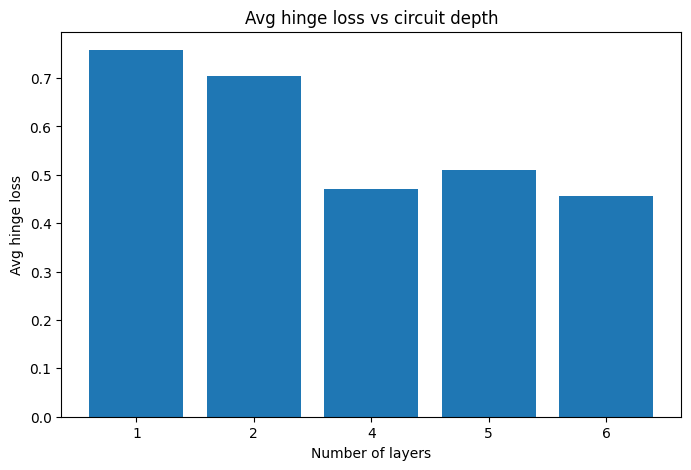

In [32]:
means = [np.mean(history_1), np.mean(history_2), np.mean(history_4), np.mean(history_5), np.mean(history_6)]

layers = ["1", "2", "4", "5", "6"]

plt.figure(figsize=(8,5))
plt.bar(layers, means)

plt.xlabel("Number of layers")
plt.ylabel("Avg hinge loss")
plt.title("Avg hinge loss vs circuit depth")

plt.show()

Loss distribution


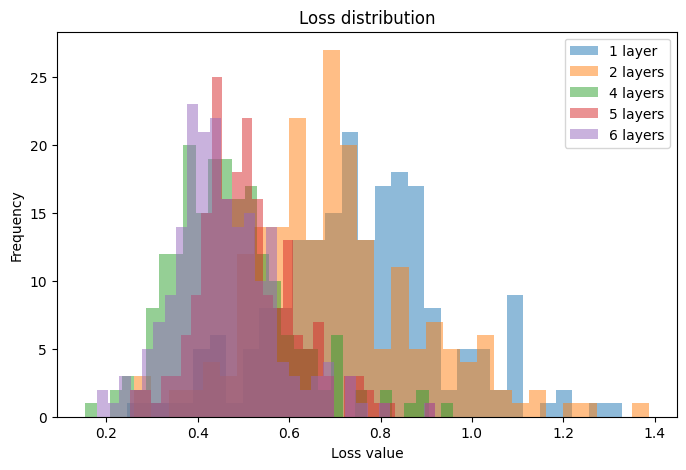

In [33]:
plt.figure(figsize=(8,5))

plt.hist(history_1, bins=30, alpha=0.5, label="1 layer")
plt.hist(history_2, bins=30, alpha=0.5, label="2 layers")
plt.hist(history_4, bins=30, alpha=0.5, label="4 layers")
plt.hist(history_5, bins=30, alpha=0.5, label="5 layers")
plt.hist(history_6, bins=30, alpha=0.5, label="6 layers")

plt.xlabel("Loss value")
plt.ylabel("Frequency")
plt.title("Loss distribution")

plt.legend()
plt.show()

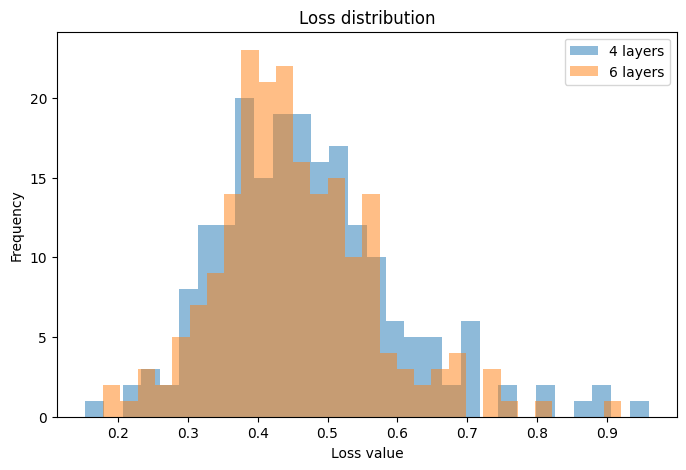

In [35]:
plt.figure(figsize=(8,5))

# plt.hist(history_1, bins=30, alpha=0.5, label="1 layer")
# plt.hist(history_2, bins=30, alpha=0.5, label="2 layers")
plt.hist(history_4, bins=30, alpha=0.5, label="4 layers")
# plt.hist(history_5, bins=30, alpha=0.5, label="5 layers")
plt.hist(history_6, bins=30, alpha=0.5, label="6 layers")

plt.xlabel("Loss value")
plt.ylabel("Frequency")
plt.title("Loss distribution")

plt.legend()
plt.show()

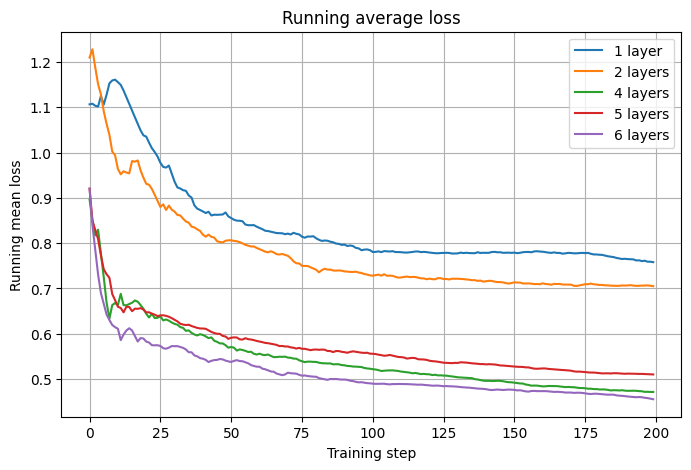

In [37]:
def running_mean(x):
    return np.cumsum(x) / np.arange(1, len(x) + 1)

plt.figure(figsize=(8,5))

plt.plot(running_mean(history_1), label="1 layer")
plt.plot(running_mean(history_2), label="2 layers")
plt.plot(running_mean(history_4), label="4 layers")
plt.plot(running_mean(history_5), label="5 layers")
plt.plot(running_mean(history_6), label="6 layers")

plt.xlabel("Training step")
plt.ylabel("Running mean loss")
plt.title("Running average loss")

plt.legend()
plt.grid(True)

plt.show()

High variance -> usntable training